# Finance Liquor Sales

## Importing the libraries

In [1]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import seaborn.objects as so
import matplotlib.pyplot as plt
import plotly.graph_objects as go

## Loading the dataset

In [2]:
df = pd.read_csv("https://storage.googleapis.com/courses_data/Assignment%20CSV/finance_liquor_sales.csv")

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   invoice_and_item_number  200 non-null    object        
 1   date                     200 non-null    datetime64[ns]
 2   store_number             200 non-null    int64         
 3   store_name               200 non-null    object        
 4   address                  200 non-null    object        
 5   city                     200 non-null    object        
 6   zip_code                 200 non-null    float64       
 7   store_location           182 non-null    object        
 8   county_number            199 non-null    float64       
 9   county                   199 non-null    object        
 10  category                 197 non-null    float64       
 11  category_name            191 non-null    object        
 12  vendor_number            200 non-nul

## Changing type

In [3]:
df["date"] = pd.to_datetime(df["date"])
filtered_df = df[(df["date"].dt.year >= 2016) & (df["date"].dt.year <= 2019)].reset_index()
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   index                    78 non-null     int64         
 1   invoice_and_item_number  78 non-null     object        
 2   date                     78 non-null     datetime64[ns]
 3   store_number             78 non-null     int64         
 4   store_name               78 non-null     object        
 5   address                  78 non-null     object        
 6   city                     78 non-null     object        
 7   zip_code                 78 non-null     float64       
 8   store_location           69 non-null     object        
 9   county_number            77 non-null     float64       
 10  county                   77 non-null     object        
 11  category                 75 non-null     float64       
 12  category_name            69 non-null  

## Grouping data based on zip_code and item_number

In [4]:
bottles_sold = filtered_df.groupby(["zip_code", "item_number"])["bottles_sold"].sum().reset_index()

In [5]:
# zip_code into int()
bottles_sold["zip_code"] = bottles_sold["zip_code"].astype(int)

## Grouping data based on zip_code

In [6]:
idx = bottles_sold.groupby("zip_code")["bottles_sold"].idxmax()
max_bottles = bottles_sold.loc[idx].reset_index()

## Sorting values in descending order

In [7]:
sorted_values = max_bottles.sort_values(by="bottles_sold", ascending=False).head(20)

## Calculating sales

In [8]:
total_sales = sum(filtered_df["sale_dollars"])

In [9]:
sales = filtered_df.groupby("store_name")["sale_dollars"].sum()

In [10]:
percentage_sales = (sales * 100 / total_sales).round(2)

In [11]:
percentage_sorted_sales = percentage_sales.sort_values(ascending=True).tail(15)

In [12]:
percentage_sorted_sales

store_name
Fareway Stores #153  /  W Des Moines     2.11
Fareway Stores #067 / Evansdale          2.11
Hy-Vee / Waukee                          2.38
Hy-Vee Food Store / Fort Dodge           2.45
Hy-Vee Food Store #2 / Waterloo          3.12
Hy-Vee Food Store #3 / Waterloo          3.53
Fareway Stores #138 / Pleasant Hill      3.60
Central City 2                           4.04
Hy-Vee Wine and Spirits / WDM            5.28
Cedar Ridge Vineyards                    5.82
Sam's Club 6568 / Ames                   6.13
Hy-Vee #3 / BDI / Des Moines             6.46
Sam's Club 6514 / Waterloo               8.14
Sam's Club 6432 / Sioux City            10.40
Wilkie Liquors                          18.20
Name: sale_dollars, dtype: float64

## Data Vizualization

## Bottles sold

<Axes: xlabel='zip_code', ylabel='bottles_sold'>

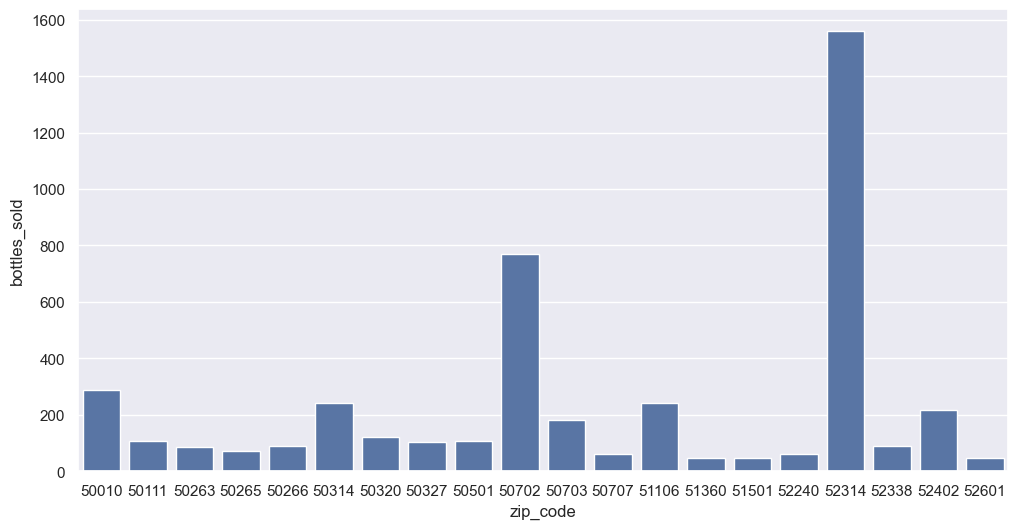

In [13]:
plt.figure(figsize=(12,6))
sns.set_theme()
sns.barplot(sorted_values, x = "zip_code", y = "bottles_sold")

<Axes: xlabel='zip_code', ylabel='bottles_sold'>

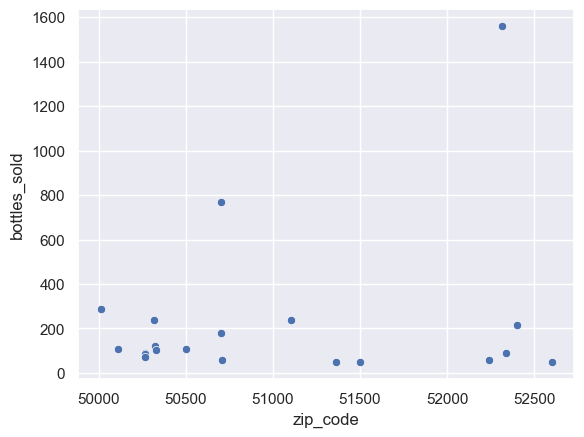

In [14]:
sns.scatterplot(sorted_values, x = "zip_code", y = "bottles_sold")

In [23]:
sorted_values

,index,zip_code,item_number,bottles_sold
37,62,52314,75087,1560
19,30,50702,77487,768
0,0,50010,946574,288
23,39,51106,67527,240
8,13,50314,86251,240
39,65,52402,86390,216
20,33,50703,168,180
11,19,50320,973627,120
15,24,50501,38176,108
2,2,50111,77805,108


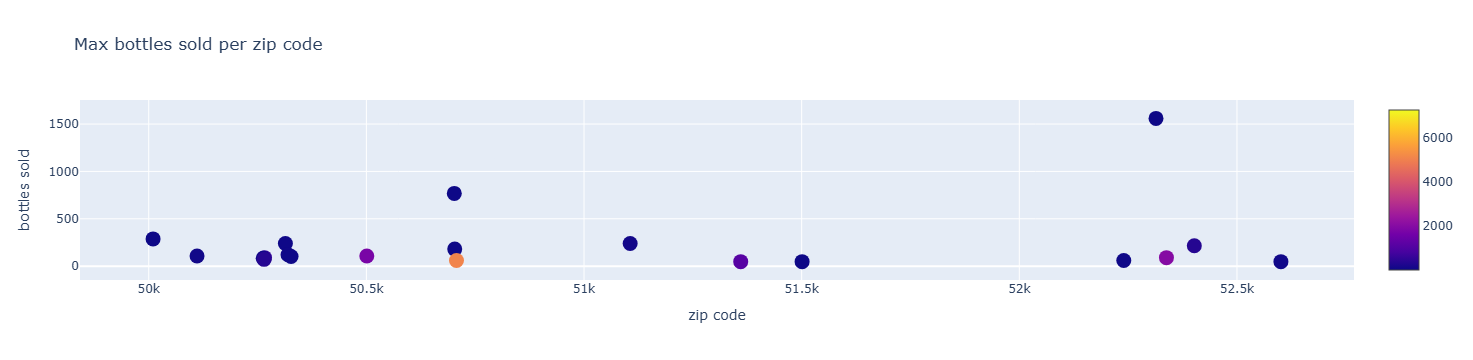

In [28]:
fig = go.Figure(
    go.Scatter(
        x=sorted_values["zip_code"],
        y=sorted_values["bottles_sold"],
        mode="markers",
        marker=dict(
            size=15, 
            color= df['sale_dollars'], # Set the marker colors
            showscale=True # Display a color scale
        ),
        text=df["item_number"]
    )
)

# Update the layout of the scatter plot
fig.update_layout(
    title="Max bottles sold per zip code",
    xaxis_title="zip code",
    yaxis_title="bottles sold",
)

# Display the scatter plot
fig.show()

In [16]:
"""plt.figure(figsize=(10,6))
plt.bar(sorted_values["zip_code"].astype(str), sorted_values["bottles_sold"], color="skyblue")
plt.xlabel("Zip Code")
plt.ylabel("Bottles Sold")
plt.title("Max bottles sold per zip code")
plt.xticks(rotation=45)
plt.show() """

'plt.figure(figsize=(10,6))\nplt.bar(sorted_values["zip_code"].astype(str), sorted_values["bottles_sold"], color="skyblue")\nplt.xlabel("Zip Code")\nplt.ylabel("Bottles Sold")\nplt.title("Max bottles sold per zip code")\nplt.xticks(rotation=45)\nplt.show() '

## Sales by store

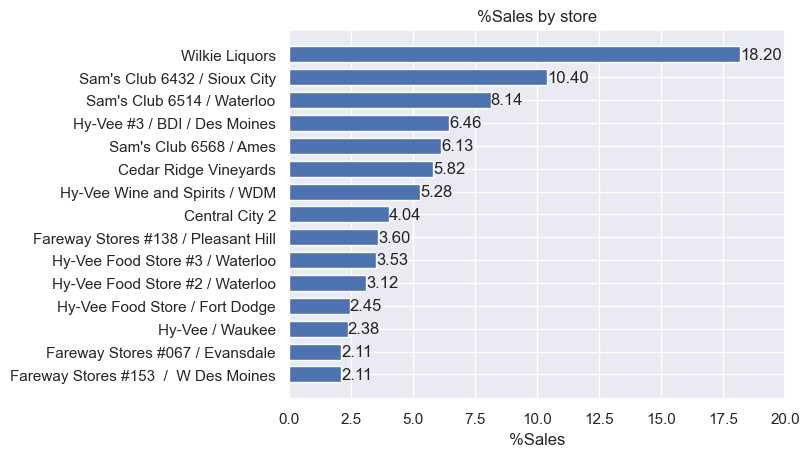

In [17]:
p = plt.barh(percentage_sorted_sales.index, percentage_sorted_sales.values, height=0.7)
plt.title("%Sales by store")
plt.xlabel("%Sales", fontsize=12)
plt.bar_label(p, fmt="%.2f")
plt.xlim([0,20])
plt.show() 

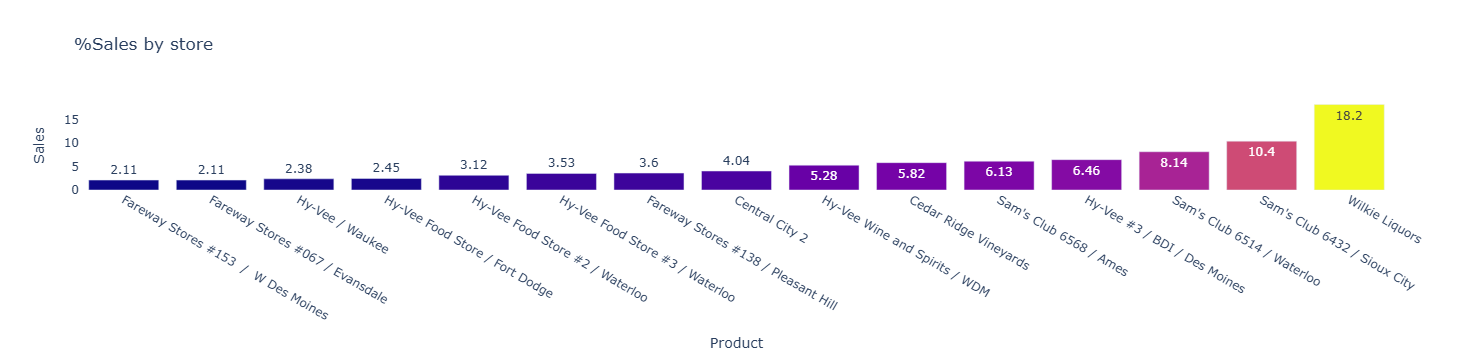

In [32]:
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=percentage_sorted_sales.index,
        y=percentage_sorted_sales.values,
        text=percentage_sorted_sales.values,
        textposition="auto",
        marker_color=percentage_sorted_sales.values,
        #orientation="h"
        
    )
)



fig.update_layout(
    title="%Sales by store",
    xaxis_title="Product",
    yaxis_title="Sales",
    plot_bgcolor="rgba(0, 0, 0, 0)",
    hovermode="x unified",
)


fig.show()